In [1]:
from pathlib import Path
from collections.abc import Hashable
from typing import Generator
from anndata import AnnData
from itertools import product

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from anndata import AnnData
from numpy.typing import NDArray
from pandas import DataFrame
from scipy.stats import spearmanr

from utils import (
    group_by_common_obs, 
    mean_randomized_cross_feature_prediction
)
from nmf_utils import nmf_predictor
from tangram_utils import tangram_predictor

In [3]:

import tangram as tg

In [11]:
def _adata_sp() -> AnnData:
    adata_sp: AnnData = sc.read(
        Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
    ).transpose()
    obs: DataFrame = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
    adata_sp.obs = obs
    adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
    #adata_sp = adata_sp[adata_sp.obs["celltype"] == celltype].copy()
    return adata_sp



def _adata_sc() -> AnnData:
    adata_sc: AnnData = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
    adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
    #adata_sc = adata_sc[adata_sc.obs["celltype"] == celltype].copy()
    adata_sc.X = adata_sc.X.toarray()
    return adata_sc

adata_sp: AnnData = _adata_sp()
adata_sc: AnnData = _adata_sc()

assert isinstance(adata_sp.X, np.ndarray)
assert isinstance(adata_sc.X, np.ndarray)

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = np.intersect1d(adata_sp.var_names, adata_sc.var_names)

print(f"{adata_sp=}\n{adata_sc=}")
print(f"{len(shared_genes)=}")

adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'
adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
len(shared_genes)=203


In [5]:
adata_sp = adata_sp[adata_sp.obs["celltype"] == "Stem/TA"]
adata_sc = adata_sc[adata_sc.obs["celltype"] == "Stem/TA"]

In [10]:
methods = {
    "nmf": lambda query_matrix, reference_matrix: nmf_predictor(query_matrix, reference_matrix, n_components=3, max_iter=1000),
    "tangram": tangram_predictor
}

In [12]:
results = []

for (method_name, method), (celltype, query, reference) in product(methods.items(), group_by_common_obs(adata_sp, adata_sc, "celltype")):
    query_matrix = query[:, shared_genes].X
    reference_matrix = reference[:, shared_genes].X
    assert all(isinstance(m, np.ndarray) for m in (query_matrix, reference_matrix))
    
    reconstructed_counts = mean_randomized_cross_feature_prediction(
        query_matrix,
        reference_matrix,
        method,
        2,
        seed=5
    )
    
    score = float(spearmanr(query_matrix.mean(axis=0), reconstructed_counts.mean(axis=0))[0])
    results.append(((method_name, celltype), (query_matrix, reconstructed_counts)))

df = pd.DataFrame(results, columns=["index", "score"])
df.set_index("index", inplace=True)
df.index = pd.MultiIndex.from_tuples(df.index, names=["method", "celltype"])

INFO:root:135 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:135 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 135 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.144, KL reg: 0.353
Score: 0.581, KL reg: 0.004
Score: 0.585, KL reg: 0.004
Score: 0.586, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004
Score: 0.587, KL reg: 0.004


INFO:root:Saving results..
INFO:root:135 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:135 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 135 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.112, KL reg: 0.386
Score: 0.450, KL reg: 0.003
Score: 0.455, KL reg: 0.003
Score: 0.456, KL reg: 0.003
Score: 0.456, KL reg: 0.003
Score: 0.456, KL reg: 0.003
Score: 0.457, KL reg: 0.003
Score: 0.457, KL reg: 0.003
Score: 0.457, KL reg: 0.003
Score: 0.457, KL reg: 0.003


INFO:root:Saving results..
INFO:root:136 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:136 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 136 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


...

Score: 0.181, KL reg: 0.001
Score: 0.090, KL reg: 0.499
Score: 0.172, KL reg: 0.002
Score: 0.177, KL reg: 0.002
Score: 0.178, KL reg: 0.002
Score: 0.179, KL reg: 0.002
Score: 0.179, KL reg: 0.002
Score: 0.179, KL reg: 0.002
Score: 0.179, KL reg: 0.002
Score: 0.179, KL reg: 0.002


INFO:root:Saving results..
INFO:root:136 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:136 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 136 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.179, KL reg: 0.002
Score: 0.084, KL reg: 0.415
Score: 0.163, KL reg: 0.001
Score: 0.166, KL reg: 0.001
Score: 0.166, KL reg: 0.001
Score: 0.167, KL reg: 0.001
Score: 0.167, KL reg: 0.001
Score: 0.167, KL reg: 0.001
Score: 0.167, KL reg: 0.001
Score: 0.167, KL reg: 0.001


INFO:root:Saving results..


Score: 0.167, KL reg: 0.001


In [19]:
df_spearman = pd.DataFrame(df["score"].map(lambda t: float(spearmanr(t[0].mean(axis=0), t[1].mean(axis=0))[0])))

<generator object group_by_common_obs at 0x137f9f3e0>

In [ ]:
def placeholder()

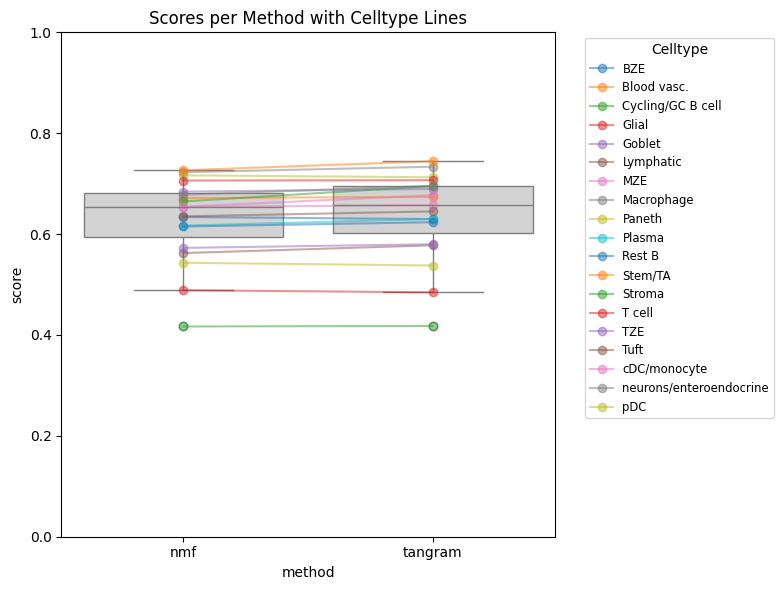

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_reset = df_spearman.reset_index()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")

for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
plt.title("Scores per Method with Celltype Lines")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
from collections.abc import Hashable
from typing import Generator, Iterable
from anndata import AnnData
import numpy as np


def group_by_obs(
    adata: AnnData,
    obs_column: str,
    values: Iterable[Hashable],
) -> Generator[tuple[Hashable, AnnData], None, None]:
    """
    Yields (value, adata_subset) for each value in `values` found in `adata.obs[obs_column]`.

    Parameters:
        adata: AnnData object to filter
        obs_column: Column in .obs to group by
        values: Iterable of values to filter on

    Yields:
        (value, adata[obs_column == value]) for each value found in the obs_column
    """
    for value in values:
        if value in adata.obs[obs_column].values:
            yield value, adata[adata.obs[obs_column] == value].copy()


def group_by_common_obs(
    adata1: AnnData,
    adata2: AnnData,
    obs_column: str,
) -> Generator[tuple[Hashable, AnnData, AnnData], None, None]:
    """
    Yields (value, adata1_subset, adata2_subset) for each value shared in the given .obs column.

    Both AnnData objects are filtered to include only rows (cells) where the specified column
    has a shared value.

    Example:
        adata1.obs[obs_column] = [A, B, C]
        adata2.obs[obs_column] = [B, C, D]

    Yields:
        ("B", adata1[obs == "B"], adata2[obs == "B"])
        ("C", adata1[obs == "C"], adata2[obs == "C"])
    """
    common_values = np.intersect1d(
        adata1.obs[obs_column].unique(),
        adata2.obs[obs_column].unique()
    )
    grouped1 = dict(group_by_obs(adata1, obs_column, common_values))
    grouped2 = dict(group_by_obs(adata2, obs_column, common_values))

    for value in common_values:
        yield value, grouped1[value], grouped2[value]

In [32]:
df.reset_index()

,method,celltype,score
0,nmf1,BZE,0.633853
1,nmf1,Blood vasc.,0.671552
2,nmf1,Cycling/GC B cell,0.416870
3,nmf1,Glial,0.488644
4,nmf1,Goblet,0.684159
5,nmf1,Lymphatic,0.562382
6,nmf1,MZE,0.653648
7,nmf1,Macrophage,0.722639
8,nmf1,Paneth,0.716413
9,nmf1,Plasma,0.616911
